## Binned Noise Statistics

In [1]:
import os
from pathlib import Path

import h5py
import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap as LSC
from scipy.stats import median_abs_deviation as mad

from embers_passes import PassFile

import mwa_hyperbeam
# wget http://ws.mwatelescope.org/static/mwa_full_embedded_element_pattern.h5
os.environ["MWA_BEAM_FILE"] = "../../hyperbeam/mwa_full_embedded_element_pattern.h5"

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

In [2]:
def passes_to_healpix_dict(
    passes,
    nside: int = 32,
    min_alt_deg: float = 0.0,
) -> list[dict[int, list[float]]]:
    """
    Bin satellite-pass power samples into per-pixel dictionaries.

    Each HEALPix pixel contains a dictionary mapping the pass index to the
    list of power samples contributed by that pass.

    Parameters
    ----------
    passes
        Satellite-pass records. Each record must provide the attributes
        ``alt_deg``, ``az_deg``, and ``power_db``.
    nside
        HEALPix resolution parameter.
    min_alt_deg
        Minimum altitude, in degrees, of samples to include.

    Returns
    -------
    power_values
        List of length ``hp.nside2npix(nside)``.

        Each element is a dictionary whose keys are pass indices and whose
        values are lists of power samples from that pass that fell into the
        corresponding HEALPix pixel.
    """
    npix = hp.nside2npix(nside)

    power_values: list[dict[int, list[float]]] = [
        {} for _ in range(npix)
    ]

    for pass_idx, pass_record in enumerate(passes):
        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)

        if not (
            alt_deg.shape == az_deg.shape == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        valid = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
            & (alt_deg > min_alt_deg)
        )

        if not np.any(valid):
            continue

        theta = np.radians(90.0 - alt_deg[valid])
        phi = np.radians(az_deg[valid])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        for pixel, power in zip(
            pixels,
            power_db[valid],
        ):
            pixel_dict = power_values[pixel]

            if pass_idx not in pixel_dict:
                pixel_dict[pass_idx] = []

            pixel_dict[pass_idx].append(float(power))

    return power_values

In [3]:
passfile = PassFile("../passes/monotonic_concave_5hz_pval/S06XX_rf0XX_passes.h5")
passes = passfile.read_passes(pointing=0)
power_values = passes_to_healpix_dict(passes)

In [4]:
npix = len(power_values)

power_map = np.full(npix, np.nan, dtype=float)
mad_map = np.full(npix, np.nan, dtype=float)
count_map = np.zeros(npix, dtype=int)

for pixel, pixel_dict in enumerate(power_values):
    if not pixel_dict:
        continue

    # Flatten all samples from all passes into one array
    values = np.concatenate(
        [np.asarray(samples, dtype=float) for samples in pixel_dict.values()]
    )

    count_map[pixel] = values.size
    power_map[pixel] = np.median(values)
    mad_map[pixel] = mad(
        values,
        scale="normal",
        nan_policy="omit",
    )

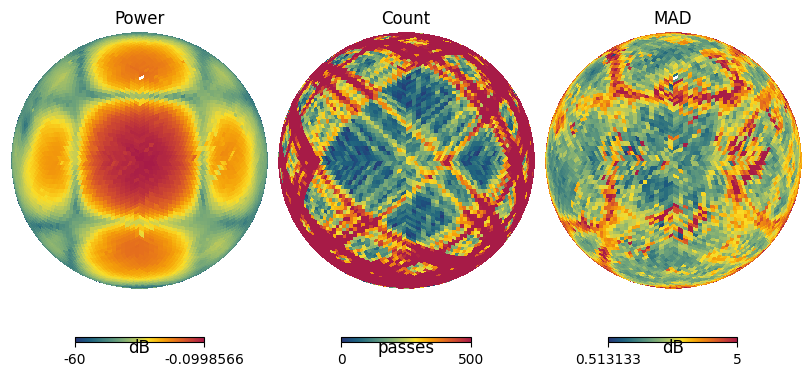

In [5]:
fig = plt.figure(figsize=(8, 9.6))

hp.orthview(power_map, fig=fig, sub=(1, 3, 1), rot=(0, 90, 180), half_sky=True, title="Power", unit="dB", cmap=prd, min=-60)
hp.orthview(count_map, fig=fig, sub=(1, 3, 2), rot=(0, 90, 180), half_sky=True, title="Count", unit="passes", cmap=prd, max=500)
hp.orthview(mad_map, fig=fig, sub=(1, 3, 3), rot=(0, 90, 180), half_sky=True, title="MAD", unit="dB", cmap=prd, max=5)

In [6]:
nside=32
npix = hp.nside2npix(nside)
theta, phi = hp.pix2ang(nside, np.arange(npix))
za_deg = np.degrees(theta)

In [7]:
interesting = (
    (za_deg < 25)
    & (count_map > 300)
    & np.isfinite(mad_map)
)

interesting_idx = np.where(interesting)[0]
print(interesting_idx)

[  5  15  38  46  68 114 115 116 117 122 123 124 146 149 150 152 155 156
 157 159 160 180 188 189 191 198 229 231 232 242 275 276 288 311 322 324
 325 326 330 339 362 376 377 378 379 393 433 437 441 452 477 498 515]


In [9]:
interesting_idx.shape

(53,)

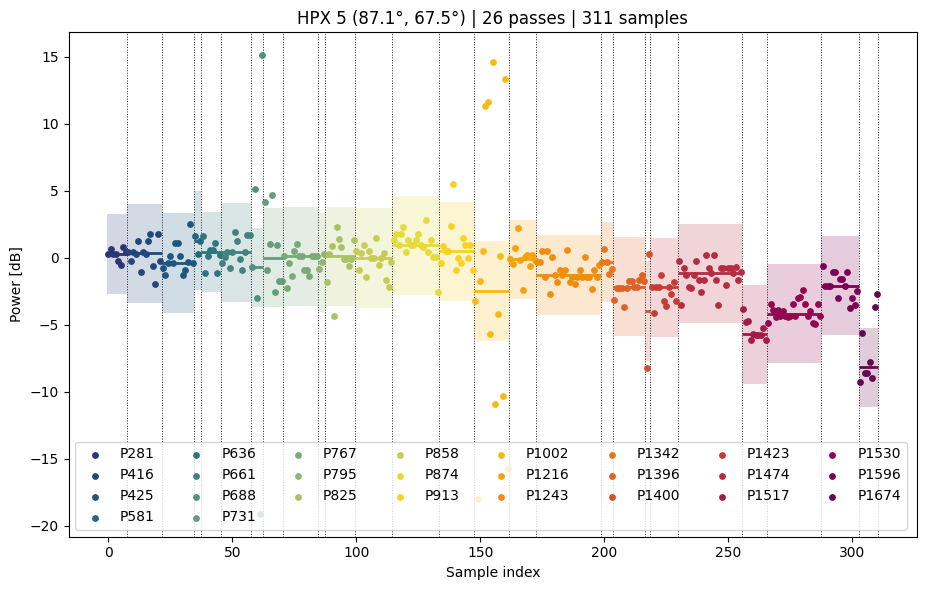

In [19]:
sel_idx = 0
pix = interesting_idx[sel_idx]
data = power_values[pix]

fig, ax = plt.subplots(figsize=(10, 6))

colors = cmr.pride(np.linspace(0.1, 0.9, len(data)))

offset = 0

for i, (pass_idx, samples) in enumerate(data.items()):
    samples = np.asarray(samples, dtype=float)
    rfe_noise_db = float(passes[pass_idx].noise_db)

    x_start = offset
    x_stop = offset + len(samples)
    x = np.arange(x_start, x_stop)

    median_power = np.median(samples)

    ax.scatter(
        x,
        samples,
        color=colors[i],
        s=15,
        label=f"P{pass_idx}",
        zorder=3,
    )

    ax.hlines(
        median_power,
        xmin=x_start - 0.5,
        xmax=x_stop - 0.5,
        color=colors[i],
        lw=2,
        zorder=4,
    )

    ax.fill_between(
        [x_start - 0.5, x_stop - 0.5],
        median_power - rfe_noise_db,
        median_power + rfe_noise_db,
        color=colors[i],
        alpha=0.2,
        linewidth=0,
        zorder=1,
    )

    ax.axvline(
        x_stop - 0.5,
        color="#222",
        ls=":",
        lw=0.7,
        zorder=2,
    )

    offset = x_stop

ax.set_xlabel("Sample index")
ax.set_ylabel("Power [dB]")
ax.legend(ncols=8)

theta, phi = hp.pix2ang(nside, pix)

alt_deg = 90.0 - np.degrees(theta)
az_deg = np.degrees(phi)

ax.set_title(
    f"HPX {pix} ({alt_deg:.1f}°, {az_deg:.1f}°) | "
    f"{len(data)} passes | "
    f"{sum(map(len, data.values()))} samples"
)
plt.tight_layout()

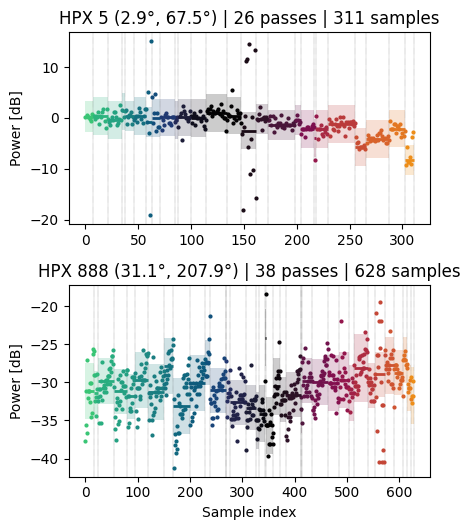

In [32]:
pix_values = [5, 888]

fig, axes = plt.subplots(
    2, 1,
    figsize=(4.5, 5.4),
    sharex=False,
)

for ax, pix in zip(axes, pix_values):
    data = power_values[pix]

    colors = cmr.wildfire(np.linspace(0.1, 0.9, len(data)))

    offset = 0

    for i, (pass_idx, samples) in enumerate(data.items()):
        samples = np.asarray(samples, dtype=float)
        rfe_noise_db = float(passes[pass_idx].noise_db)

        x_start = offset
        x_stop = offset + len(samples)
        x = np.arange(x_start, x_stop)

        median_power = np.median(samples)

        ax.scatter(
            x,
            samples,
            color=colors[i],
            s=4,
            label=f"P{pass_idx}",
            zorder=3,
        )

        ax.hlines(
            median_power,
            xmin=x_start - 0.5,
            xmax=x_stop - 0.5,
            color=colors[i],
            lw=2,
            zorder=4,
        )

        ax.fill_between(
            [x_start - 0.5, x_stop - 0.5],
            median_power - rfe_noise_db,
            median_power + rfe_noise_db,
            color=colors[i],
            alpha=0.2,
            linewidth=0,
            zorder=1,
        )

        ax.axvline(
            x_stop - 0.5,
            color="#222",
            ls=":",
            lw=0.3,
            zorder=2,
        )

        offset = x_stop

    theta, phi = hp.pix2ang(nside, pix)

    za_deg = np.degrees(theta)
    az_deg = np.degrees(phi)

    ax.set_ylabel("Power [dB]")

    ax.set_title(
        f"HPX {pix} ({za_deg:.1f}°, {az_deg:.1f}°) | "
        f"{len(data)} passes | "
        f"{sum(map(len, data.values()))} samples"
    )

axes[-1].set_xlabel("Sample index")

plt.tight_layout()

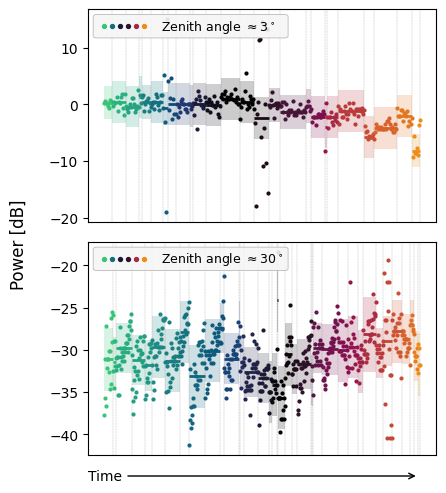

In [55]:
from matplotlib import patches
pix_values = [5, 888]

fig, axes = plt.subplots(
    2, 1,
    figsize=(4.5, 5.0),
    sharex=False,
)

for ax, pix in zip(axes, pix_values):
    data = power_values[pix]

    colors = cmr.wildfire(np.linspace(0.1, 0.9, len(data)))
    offset = 0

    for i, (pass_idx, samples) in enumerate(data.items()):
        samples = np.asarray(samples, dtype=float)
        rfe_noise_db = float(passes[pass_idx].noise_db)

        x_start = offset
        x_stop = offset + len(samples)
        x = np.arange(x_start, x_stop)

        median_power = np.median(samples)

        ax.scatter(
            x,
            samples,
            color=colors[i],
            s=4,
            zorder=3,
        )

        ax.hlines(
            median_power,
            xmin=x_start - 0.5,
            xmax=x_stop - 0.5,
            color=colors[i],
            lw=2,
            zorder=4,
        )

        ax.fill_between(
            [x_start - 0.5, x_stop - 0.5],
            median_power - rfe_noise_db,
            median_power + rfe_noise_db,
            color=colors[i],
            alpha=0.2,
            linewidth=0,
            zorder=1,
        )

        ax.axvline(
            x_stop - 0.5,
            color="#222",
            ls=":",
            lw=0.2,
            zorder=2,
        )

        offset = x_stop

    # Zenith angle
    theta, _ = hp.pix2ang(nside, pix)
    za_deg = np.degrees(theta)

    # Fixed zenith angles for the two example pixels
    za_label = {5: 3, 888: 30}[pix]
    
    # Six dots sampling the colour progression
    legend_colors = cmr.wildfire(np.linspace(0.1, 0.9, 6))
    
    dot_x = np.linspace(0.045, 0.16, 6)
    dot_y = 0.92
    
    # White background box behind the entire annotation
    box = patches.FancyBboxPatch(
        (0.025, 0.875),
        0.54,
        0.09,
        transform=ax.transAxes,
        boxstyle="round,pad=0.01",
        facecolor="whitesmoke",
        edgecolor="0.7",
        linewidth=0.6,
        alpha=0.9,
        zorder=9,
    )
    
    ax.add_patch(box)
    
    for x_pos, color in zip(dot_x, legend_colors):
        ax.scatter(
            x_pos,
            dot_y,
            s=8,
            color=color,
            transform=ax.transAxes,
            clip_on=False,
            zorder=10,
        )
    
    ax.text(
        0.21,
        dot_y,
        rf"Zenith angle $\approx {za_label}^\circ$",
        transform=ax.transAxes,
        va="center",
        ha="left",
        fontsize=9,
        zorder=10,
    )
    # Remove the x axis entirely
    ax.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False,
    )

# One common y label
fig.supylabel("Power [dB]", x=0.02)

# Time arrow below the lower panel
axes[-1].annotate(
    "Time",
    xy=(0.95, -0.10),
    xytext=(0.05, -0.10),
    xycoords="axes fraction",
    textcoords="axes fraction",
    ha="center",
    va="center",
    arrowprops=dict(
        arrowstyle="->",
        lw=1,
        color="black",
    ),
    annotation_clip=False,
)

plt.tight_layout()
plt.savefig(f"../data/plots/passes_in_a_pixel.pdf", bbox_inches="tight", pad_inches=0.03,)